<a href="https://colab.research.google.com/github/ovtsxde/pca-image-compression-analysis/blob/main/pca-compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основной блок

## Импорты


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import kagglehub
import shutil

from PIL import Image
from IPython.display import display

import random
import os

## Определим основные директории

In [ ]:
standart_dir = 'sample_data/wonders_of_world'
kaggle_dir = "balabaskar/wonders-of-the-world-image-classification"

## Загрузка датасета в google colab

In [ ]:
if not os.path.isdir(standart_dir):
  path = kagglehub.dataset_download(kaggle_dir)
  target_path = f'/content/{standart_dir}'

  shutil.copytree(path, target_path)

## Получение датасета

In [ ]:
df = pd.read_csv(f'{standart_dir}/wonders_of_world_images.csv')
df

,folder_name,filename
0,burj_khalifa,0005487c0b.jpg
1,burj_khalifa,00d4a42317.jpg
2,burj_khalifa,01bbf1f63c.jpg
3,burj_khalifa,01f75e9545.jpg
4,burj_khalifa,020f2c752c.jpg
...,...,...
3841,venezuela_angel_falls,f8a9a1b84f.jpg
3842,venezuela_angel_falls,fcc0dd88df.jpg
3843,venezuela_angel_falls,fd5d26f3ab.jpg
3844,venezuela_angel_falls,fdb5d988af.jpg


## Переводим изображение в векторное представление

In [ ]:
data_dict = { folder:[] for folder in set(df['folder_name']) }
optimal_components_dict = {}
compression_dict = {}

img_size = (256, 256)
original_size = img_size[0] * img_size[1]

for folder_name, file_name in df.values:
  img_path = f'{standart_dir}/Wonders of World/Wonders of World/{folder_name}/{file_name}'
  img = Image.open(img_path).resize(img_size)
  img_vector = np.array(img).flatten()
  data_dict[folder_name].append(img_vector)

## Применяем **PCA** и расчитываем оптимальное количество главных компонент

Также параллельно строим графики объясненной дисперсии по классам

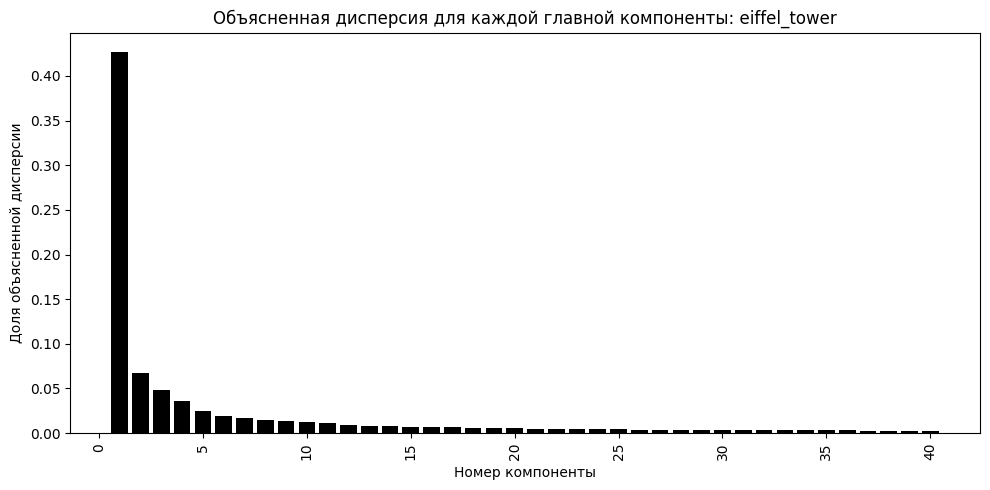

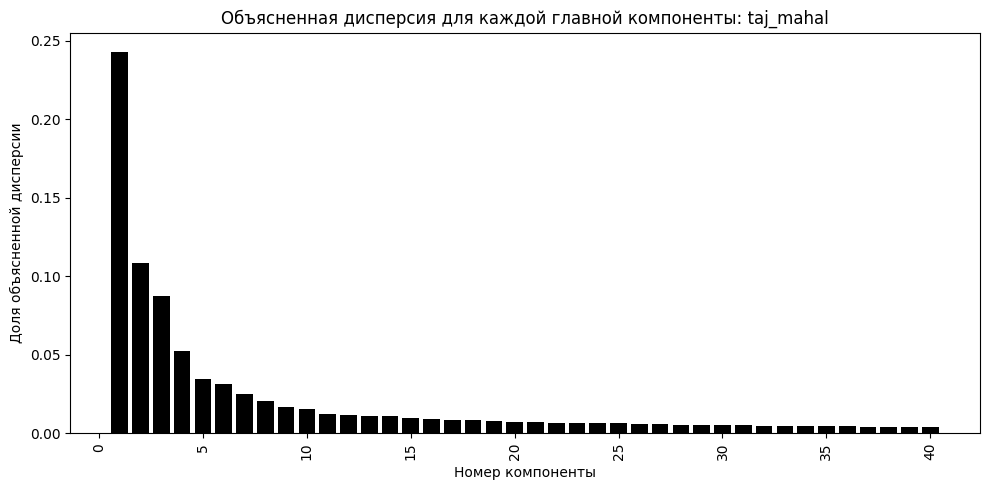

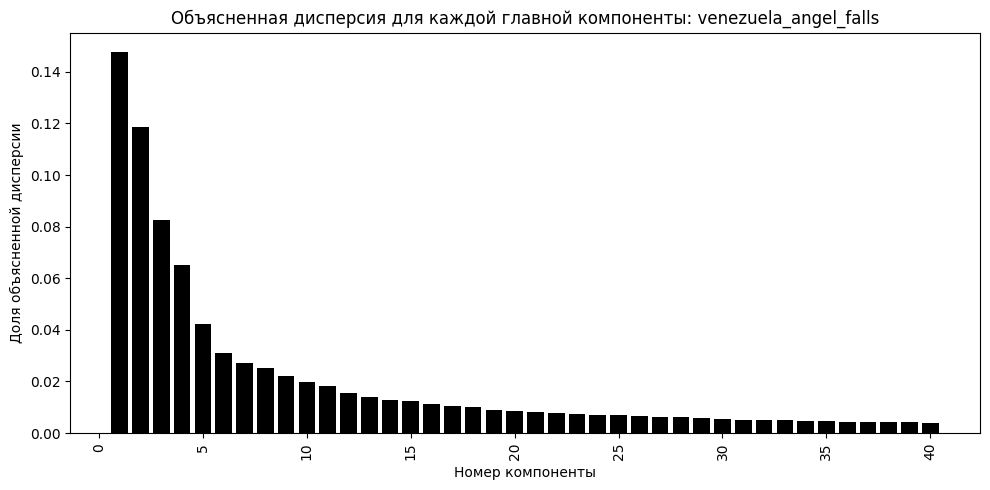

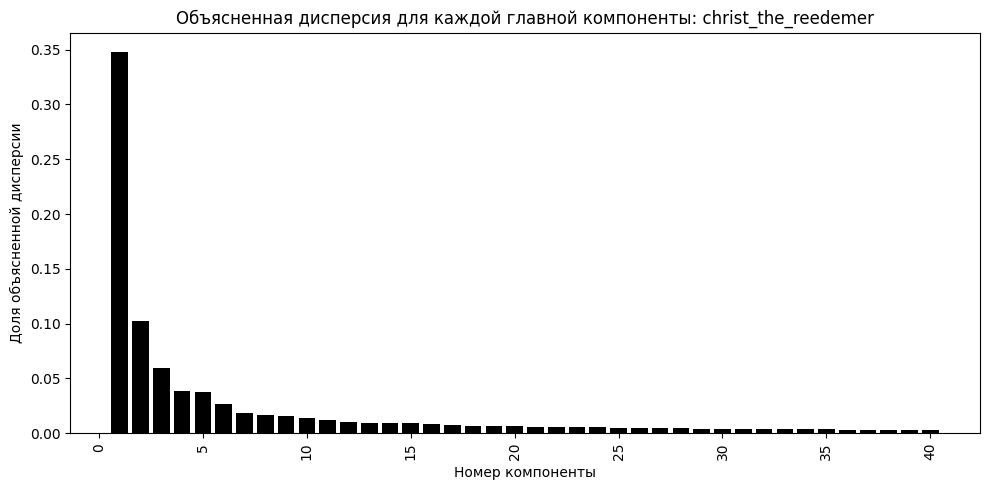

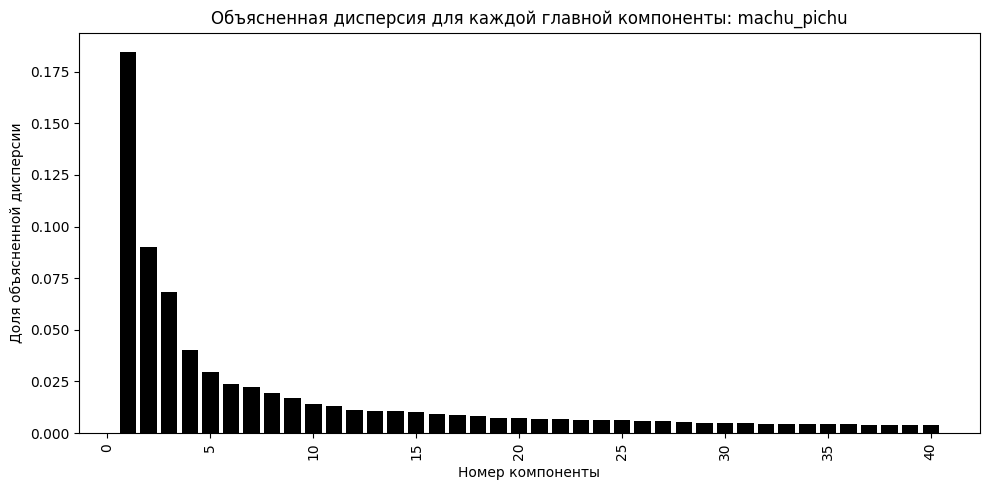

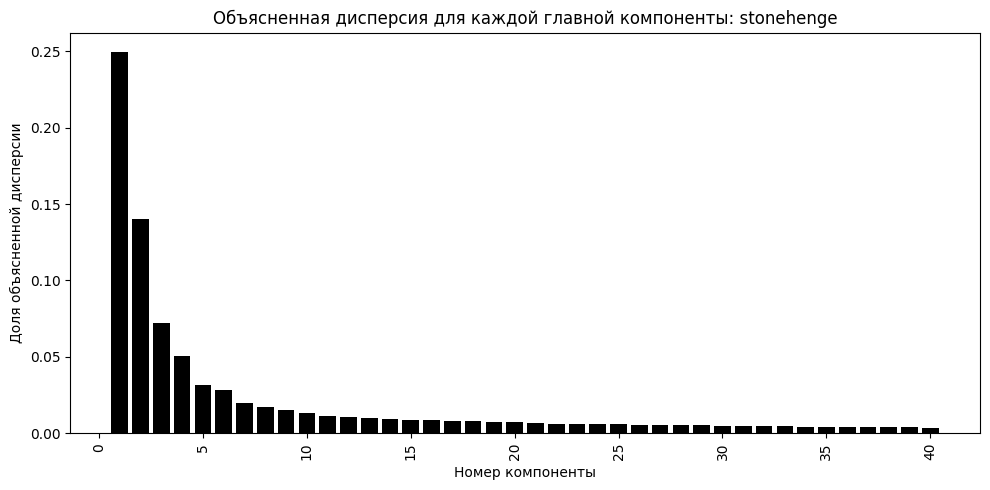

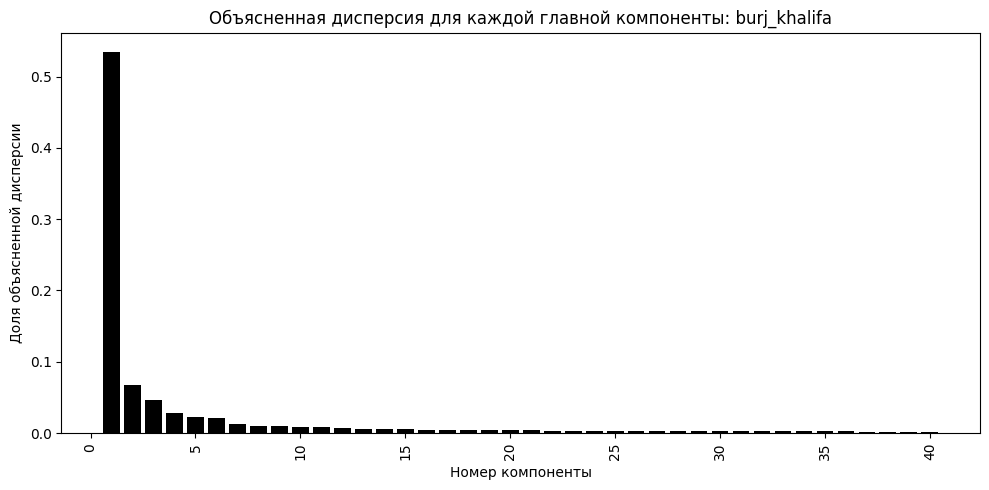

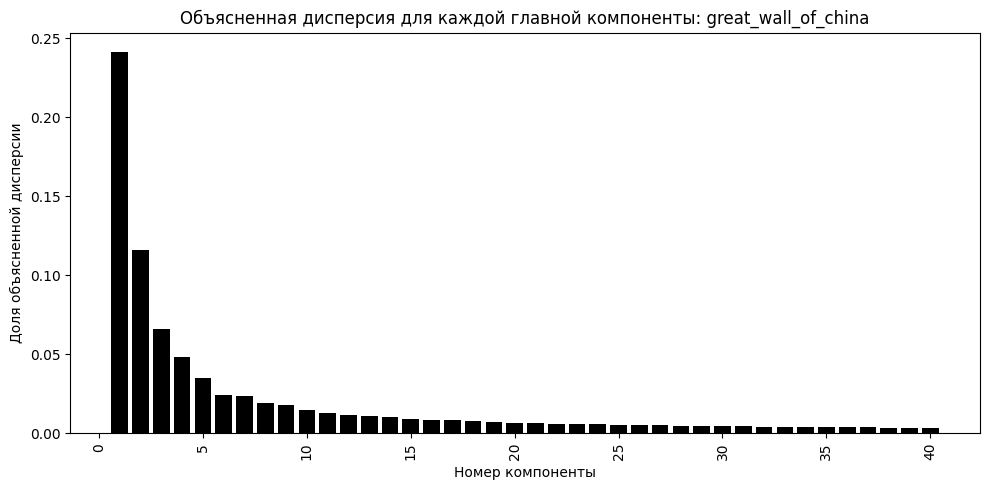

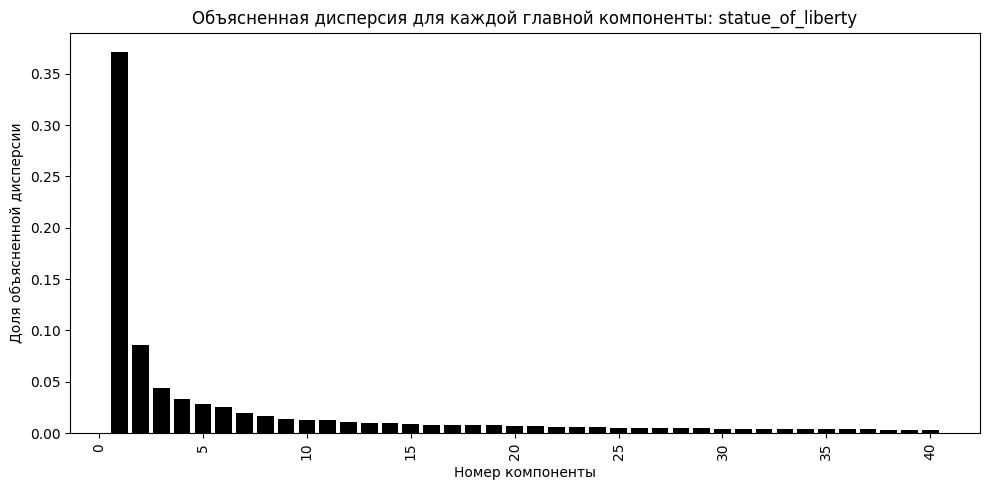

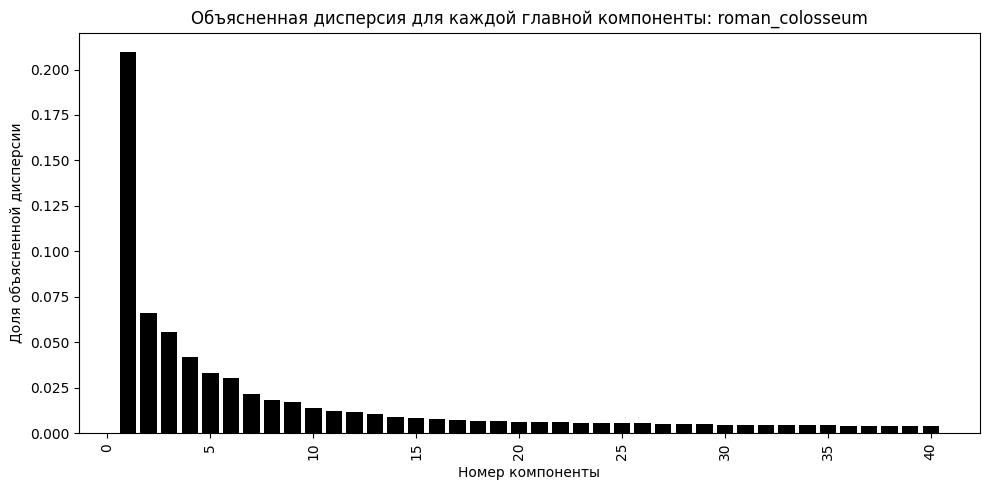

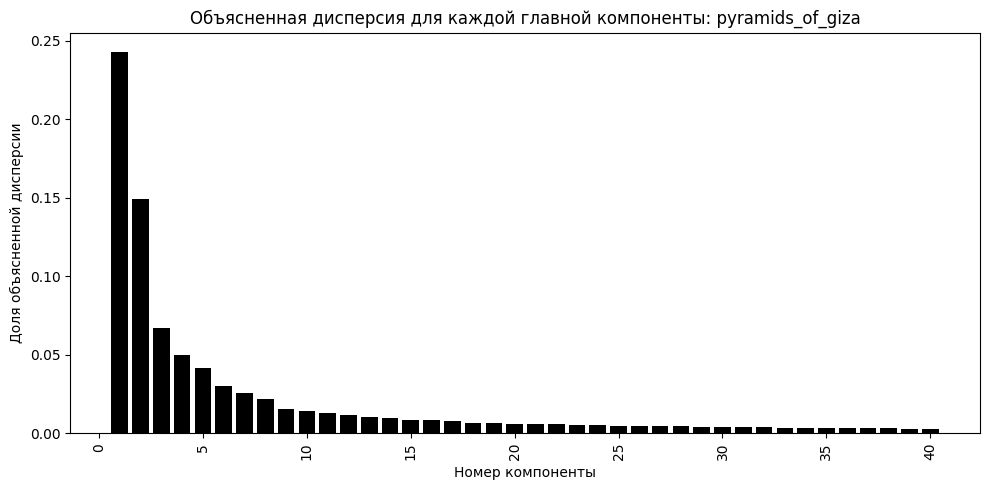

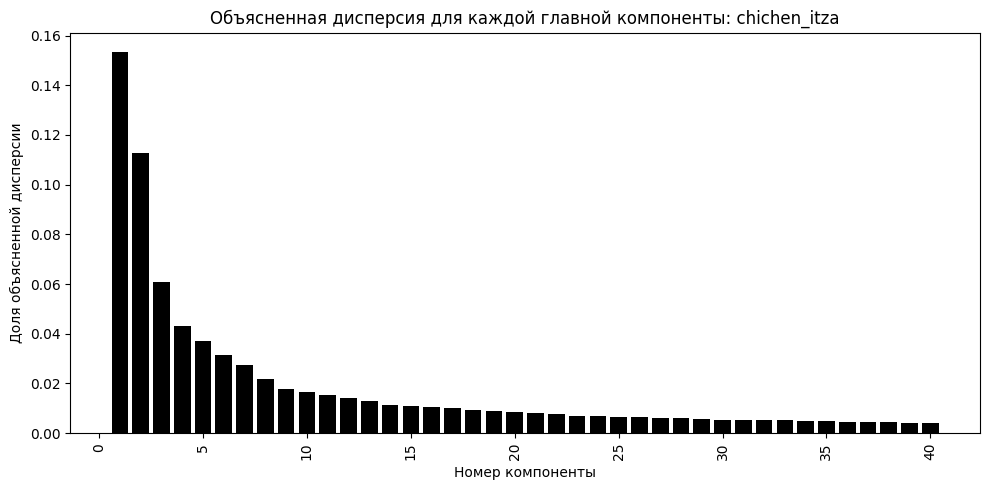

In [ ]:
explained_variance_dict = {}
for key in data_dict.keys():
  data_dict[key] = np.array(data_dict[key])

  X = data_dict[key]
  pca = PCA()
  pca.fit(X)

  cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
  optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
  compression = 1 - (optimal_components / original_size)
  optimal_components_dict[key] = optimal_components
  compression_dict[key] = compression

  explained_variance = pca.explained_variance_ratio_
  explained_variance_dict[key] = explained_variance

  plt.figure(figsize=(10, 5))
  plt.bar(range(1, 41), explained_variance[:40], width = 0.8, color = 'black', alpha=1)
  plt.title(f'Объясненная дисперсия для каждой главной компоненты: {key}')
  plt.xlabel('Номер компоненты')
  plt.ylabel('Доля объясненной дисперсии')
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

## Получившийся процент сжатия по каждому из классов

In [ ]:
for key in compression_dict.keys():
  print(f'{key}: {compression_dict[key]:.6f}')

eiffel_tower: 0.998749
taj_mahal: 0.999069
venezuela_angel_falls: 0.998962
christ_the_reedemer: 0.998962
machu_pichu: 0.998001
stonehenge: 0.998947
burj_khalifa: 0.999146
great_wall_of_china: 0.998520
statue_of_liberty: 0.998962
roman_colosseum: 0.997894
pyramids_of_giza: 0.998779
chichen_itza: 0.998444


## Получившиеся количество главных компонент по каждому из классов

In [ ]:
for key in optimal_components_dict.keys():
  print(f'{key}: {optimal_components_dict[key]}')

eiffel_tower: 82
taj_mahal: 61
venezuela_angel_falls: 68
christ_the_reedemer: 68
machu_pichu: 131
stonehenge: 69
burj_khalifa: 56
great_wall_of_china: 97
statue_of_liberty: 68
roman_colosseum: 138
pyramids_of_giza: 80
chichen_itza: 102


# Обработка полученных данных

## Строим график на основе полученных данных о оптимальном количестве компонент

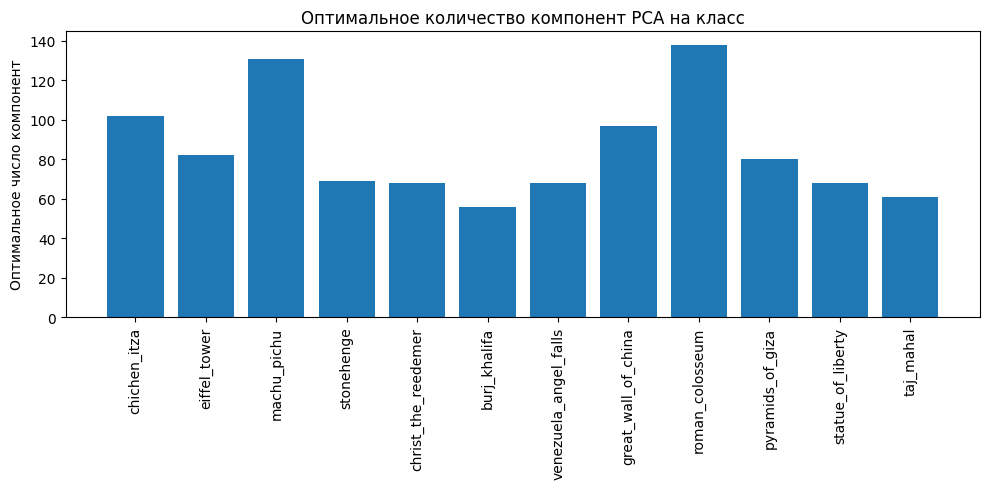

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(optimal_components_dict.keys(), optimal_components_dict.values())
plt.xticks(rotation=90)
plt.ylabel("Оптимальное число компонент")
plt.title("Оптимальное количество компонент PCA на класс")
plt.tight_layout()
plt.show()

## Строим график на основе полученных данных о экономии памяти на класс

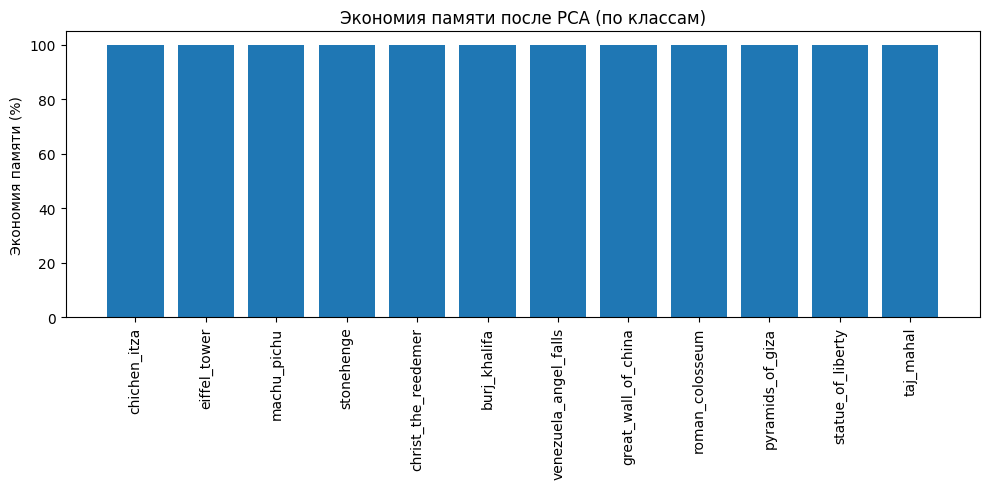

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(compression_dict.keys(), [v * 100 for v in compression_dict.values()])
plt.xticks(rotation=90)
plt.ylabel("Экономия памяти (%)")
plt.title("Экономия памяти после PCA (по классам)")
plt.tight_layout()
plt.show()